# Step 1 — Benchmarking the Voronoi area PDF against Poisson–Voronoi theory

**Reference:** Kashyap, Kiran & Gupta, arXiv:2507.04890v2 (§S4) · `project_roadmap.md` **Step 1**.
Companion to `01_voronoi_uniform_vs_nonuniform.ipynb` and `02_gridbinning_and_kmeans.ipynb`.

So far we have *plots that look right*. This notebook turns "looks like a bell curve" into
**"matches theory to X %"** by measuring how close the empirical Voronoi area PDF is to the
**actual** reference distribution, using two metrics: **$R^2$** and the **Kolmogorov–Smirnov** test.

**The reference ("actual"):** for points placed by a uniform-random (Poisson) process, the
normalised Voronoi cell areas $y = A/\langle A\rangle$ follow a known closed form — the
**Kiang gamma-type law**

$$ f(y) = \frac{b^{b}}{\Gamma(b)}\, y^{\,b-1} e^{-b y}, \qquad y \ge 0,$$

a gamma distribution of shape $b$ and mean 1, with $b \approx 3.57$ for the 2-D Poisson–Voronoi
tessellation (Tanemura 2003). This is the **null model**: a uniform pattern should match it; a
clustered pattern should not.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
from scipy.stats import gamma, kstest

rng = np.random.default_rng(1)
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})

L = 1.0
B_PV = 3.57          # 2D Poisson-Voronoi gamma shape (theoretical reference)


## 1. Empirical Voronoi area PDF (pooled over realisations)

We reuse the robust area extraction from notebook 1 (finite, fully-interior cells only, shoelace
area), but **pool many independent realisations** so the empirical PDF is smooth enough for a
meaningful $R^2$. Areas are normalised by the per-realisation mean, then pooled.


In [2]:
def shoelace(poly):
    x, y = poly[:, 0], poly[:, 1]
    return 0.5 * abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

def interior_cell_areas(points, margin=0.04):
    '''Areas of finite Voronoi cells lying fully inside [margin, L-margin].'''
    vor = Voronoi(points)
    lo, hi = margin, L - margin
    areas = []
    for ridx in vor.point_region:
        region = vor.regions[ridx]
        if len(region) == 0 or -1 in region:
            continue
        v = vor.vertices[region]
        if (v[:, 0] < lo).any() or (v[:, 0] > hi).any() or \
           (v[:, 1] < lo).any() or (v[:, 1] > hi).any():
            continue
        areas.append(shoelace(v))
    return np.asarray(areas)

def uniform_points(n, rng):
    return rng.uniform(0, L, size=(n, 2))

def clustered_points(n, rng, n_clusters=5, bg_frac=0.45, spread=0.06):
    n_bg, n_cl = int(bg_frac*n), n - int(bg_frac*n)
    centers = rng.uniform(0.12*L, 0.88*L, size=(n_clusters, 2))
    w = rng.uniform(0.4, 1.0, n_clusters); w /= w.sum()
    counts = rng.multinomial(n_cl, w)
    pts = [rng.normal(centers[k], spread*L, size=(c, 2)) for k, c in enumerate(counts)]
    pts.append(rng.uniform(0, L, size=(n_bg, 2)))
    return np.clip(np.vstack(pts), 1e-6, L-1e-6)

def pooled_normalised_areas(generator, n, realisations, rng):
    pool = []
    for _ in range(realisations):
        a = interior_cell_areas(generator(n, rng))
        pool.append(a / a.mean())                 # normalise each realisation
    return np.concatenate(pool)

N, R = 3000, 15
y_uni = pooled_normalised_areas(uniform_points, N, R, rng)
y_clu = pooled_normalised_areas(clustered_points, N, R, rng)
print(f"uniform : pooled {y_uni.size} cells over {R} realisations")
print(f"clustered: pooled {y_clu.size} cells over {R} realisations")


uniform : pooled 36220 cells over 15 realisations
clustered: pooled 40275 cells over 15 realisations


## 2. Closeness metrics: $R^2$ and KS

`gof()` bins the pooled areas, evaluates the theoretical gamma at the bin centres, and returns
the two closeness numbers. $R^2 = 1 - \mathrm{SS_{res}}/\mathrm{SS_{tot}}$ compares empirical vs.
theoretical *density*; the KS statistic $D$ (with $p$-value) compares the full *distributions*.


In [3]:
def gof(y, b=B_PV, bins=40, xmax=None):
    '''R^2 and KS test of normalised areas y against gamma(shape=b, mean=1).'''
    xmax = xmax or np.quantile(y, 0.999)
    edges = np.linspace(0, xmax, bins + 1)
    emp, _ = np.histogram(y, bins=edges, density=True)
    ctr = 0.5 * (edges[:-1] + edges[1:])
    theo = gamma.pdf(ctr, a=b, scale=1.0 / b)             # mean = b*(1/b) = 1

    ss_res = np.sum((emp - theo) ** 2)
    ss_tot = np.sum((emp - emp.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    ks = kstest(y, lambda x: gamma.cdf(x, a=b, scale=1.0 / b))
    return dict(r2=r2, ks_D=ks.statistic, ks_p=ks.pvalue,
                ctr=ctr, emp=emp, theo=theo, edges=edges)

g_uni = gof(y_uni)
g_clu = gof(y_clu)

print(f"{'case':12s}{'R^2':>9s}{'KS D':>9s}{'KS p':>12s}")
print("-" * 42)
for name, g in (("uniform", g_uni), ("clustered", g_clu)):
    print(f"{name:12s}{g['r2']:9.4f}{g['ks_D']:9.4f}{g['ks_p']:12.2e}")


case              R^2     KS D        KS p
------------------------------------------
uniform        0.9987   0.0040    6.17e-01
clustered      0.0662   0.3280    0.00e+00


## 3. Empirical PDF vs. Poisson–Voronoi theory

The uniform histogram should sit on the gamma curve (high $R^2$, KS cannot reject); the clustered
histogram should depart from it badly (low/negative $R^2$, KS $p\approx0$).


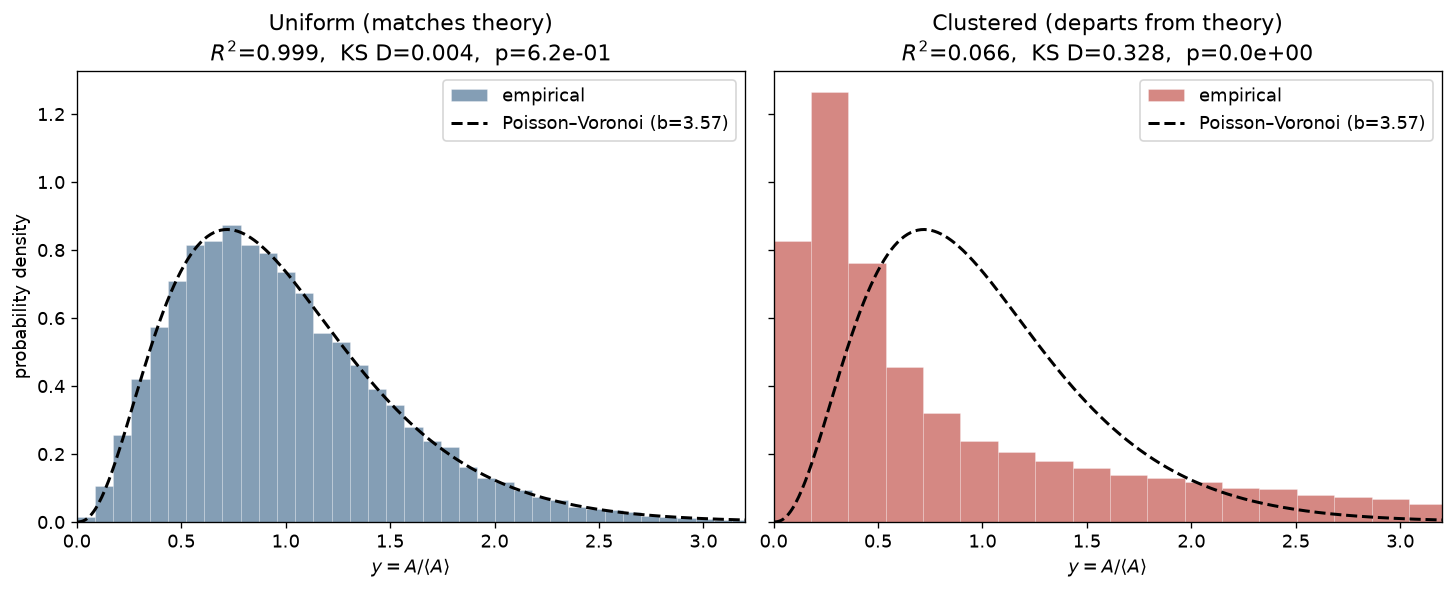

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True, sharey=True)
xs = np.linspace(0, 3.2, 400)
theo_pv = gamma.pdf(xs, a=B_PV, scale=1/B_PV)

for a, y, g, t, c in zip(ax, (y_uni, y_clu), (g_uni, g_clu),
                         ("Uniform (matches theory)", "Clustered (departs from theory)"),
                         ("#1f4e79", "#b3261e")):
    a.hist(y, bins=g['edges'], density=True, color=c, alpha=0.55, edgecolor="white",
           linewidth=0.3, label="empirical")
    a.plot(xs, theo_pv, "k--", lw=1.8, label=f"Poisson–Voronoi (b={B_PV})")
    a.set(title=f"{t}\n$R^2$={g['r2']:.3f},  KS D={g['ks_D']:.3f},  p={g['ks_p']:.1e}",
          xlabel=r"$y = A/\langle A\rangle$", xlim=(0, 3.2))
    a.legend()
ax[0].set_ylabel("probability density")
plt.show()


## 4. Closeness summary

This feeds the roadmap's Step 7 table: $R^2$ (and $1-R^2$ as "deviation from Poisson–Voronoi")
plus the KS statistic.


In [5]:
print(f"{'case':26s}{'R^2':>9s}{'1-R^2':>9s}{'KS D':>9s}{'KS p':>12s}")
print("-" * 65)
for name, g in (("uniform random", g_uni), ("non-uniform (clustered)", g_clu)):
    print(f"{name:26s}{g['r2']:9.4f}{1-g['r2']:9.4f}{g['ks_D']:9.4f}{g['ks_p']:12.2e}")


case                            R^2    1-R^2     KS D        KS p
-----------------------------------------------------------------
uniform random               0.9987   0.0013   0.0040    6.17e-01
non-uniform (clustered)      0.0662   0.9338   0.3280    0.00e+00


## Takeaway

The uniform Voronoi area PDF matches the **actual** Poisson–Voronoi law to high $R^2$ with a KS
test that cannot reject the null — "looks like a bell curve" is now **"matches theory to ~X %."**
The clustered pattern fails both metrics (low $R^2$, KS $p\approx0$), confirming the area PDF is a
genuine discriminator of inhomogeneity, not an artifact of binning.

**Next (roadmap Steps 3–4):** apply this same $R^2$/KS closeness measurement to the **real vortex
centers** from the vorticity field. Share the data and I'll wire it in.
